In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from pyarrow import feather

In [3]:
all_data = pd.read_feather(r"Downloads/Sales_data.ftr")

In [4]:
all_data.head(6)

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
0,176558,USB-C Charging Cable,2,11.95,04/19/19 08:46,"917 1st St, Dallas, TX 75001"
1,None,None,None,None,None,None
2,176559,Bose SoundSport Headphones,1,99.99,04/07/19 22:30,"682 Chestnut St, Boston, MA 02215"
3,176560,Google Phone,1,600,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"
4,176560,Wired Headphones,1,11.99,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"
5,176561,Wired Headphones,1,11.99,04/30/19 09:27,"333 8th St, Los Angeles, CA 90001"


In [88]:
all_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 185686 entries, 0 to 186849
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Order ID          185686 non-null  object 
 1   Product           185686 non-null  object 
 2   Quantity Ordered  185686 non-null  int32  
 3   Price Each        185686 non-null  float64
 4   Order Date        185686 non-null  object 
 5   Purchase Address  185686 non-null  object 
 6   Month             185686 non-null  int32  
 7   sales             185686 non-null  float64
 8   city              185686 non-null  object 
 9   Hour              185686 non-null  int32  
dtypes: float64(2), int32(3), object(5)
memory usage: 17.5+ MB


In [89]:
all_data.describe()

,Quantity Ordered,Price Each,Month,sales,Hour
count,185686.000000,185686.000000,185686.000000,185686.000000,185686.000000
mean,1.124544,184.519255,7.058653,185.611936,14.412934
std,0.443069,332.843838,3.502932,333.032118,5.423329
min,1.000000,2.990000,1.000000,2.990000,0.000000
25%,1.000000,11.950000,4.000000,11.950000,11.000000
50%,1.000000,14.950000,7.000000,14.950000,15.000000
75%,1.000000,150.000000,10.000000,150.000000,19.000000
max,9.000000,1700.000000,12.000000,3400.000000,23.000000


# Data cleaning and formatting

In [6]:
all_data.isnull().sum()

Order ID            545
Product             545
Quantity Ordered    545
Price Each          545
Order Date          545
Purchase Address    545
dtype: int64

In [7]:
all_data.shape

(186850, 6)

In [8]:
all_data = all_data.dropna(how = 'all')

In [9]:
all_data.shape

(186305, 6)

In [10]:
all_data.duplicated()

0         False
2         False
3         False
4         False
5         False
          ...  
186845    False
186846    False
186847    False
186848    False
186849    False
Length: 186305, dtype: bool

In [11]:
all_data[all_data.duplicated()]

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
31,176585,Bose SoundSport Headphones,1,99.99,04/07/19 11:31,"823 Highland St, Boston, MA 02215"
1149,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
1155,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
1302,177795,Apple Airpods Headphones,1,150,04/27/19 19:45,"740 14th St, Seattle, WA 98101"
1684,178158,USB-C Charging Cable,1,11.95,04/28/19 21:13,"197 Center St, San Francisco, CA 94016"
...,...,...,...,...,...,...
186563,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
186632,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
186738,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
186782,259296,Apple Airpods Headphones,1,150,09/28/19 16:48,"894 6th St, Dallas, TX 75001"


In [12]:
all_data = all_data.drop_duplicates()

In [13]:
all_data[all_data.duplicated()]

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address


# Which is the best month for sale ?

In [15]:
all_data.columns

Index(['Order ID', 'Product', 'Quantity Ordered', 'Price Each', 'Order Date',
       'Purchase Address'],
      dtype='object')

In [90]:
all_data['Order Date'] = pd.to_datetime(all_data['Order Date'], errors='coerce')

C:\Users\admin\AppData\Local\Temp\ipykernel_19916\4061391744.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  all_data['Order Date'] = pd.to_datetime(all_data['Order Date'], errors='coerce')


In [91]:
all_data = all_data.dropna(subset=['Order Date'])

In [92]:
all_data['Month'] = all_data['Order Date'].dt.month

In [93]:
all_data.dtypes

Order ID                    object
Product                     object
Quantity Ordered             int32
Price Each                 float64
Order Date          datetime64[ns]
Purchase Address            object
Month                        int32
sales                      float64
city                        object
Hour                         int32
dtype: object

In [28]:
all_data['Quantity Ordered'] = all_data['Quantity Ordered'].astype(int)
all_data['Price Each'] = all_data['Price Each'].astype(float)

In [30]:
all_data.dtypes

Order ID             object
Product              object
Quantity Ordered      int32
Price Each          float64
Order Date           object
Purchase Address     object
Month                 int32
dtype: object

In [95]:

all_data['sales'] = all_data['Quantity Ordered'] * all_data['Price Each']

In [96]:
all_data.groupby(['Month'])['sales'].sum()

Month
1     1821413.16
2     2200078.08
3     2804973.35
4     3389217.98
5     3150616.23
6     2576280.15
7     2646461.32
8     2241083.37
9     2094465.69
10    3734777.86
11    3197875.05
12    4608295.70
Name: sales, dtype: float64

<Axes: xlabel='Month'>

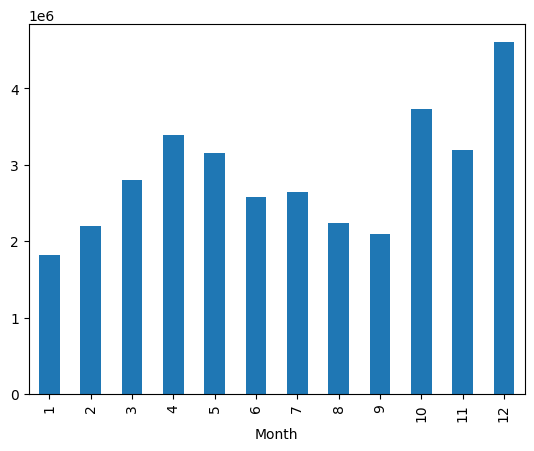

In [34]:
all_data.groupby(['Month'])['sales'].sum().plot(kind='bar')

__Monthly sales analysis shows a clear peak in December, likely driven by seasonal demand and holiday shopping trends. This suggests opportunities for targeted promotions and inventory planning during Q4__

# Which city has max order ? 

In [38]:
all_data['Purchase Address'][0]

'917 1st St, Dallas, TX 75001'

In [39]:
all_data['Purchase Address'][0].split(',')[1] 

' Dallas'

In [40]:
all_data['city'] = all_data['Purchase Address'].str.split(',').str.get(1)

In [41]:
all_data['city']

0                 Dallas
2                 Boston
3            Los Angeles
4            Los Angeles
5            Los Angeles
               ...      
186845       Los Angeles
186846     San Francisco
186847     San Francisco
186848     San Francisco
186849     San Francisco
Name: city, Length: 185686, dtype: object

In [42]:
pd.value_counts(all_data['city']) ## frequency table..

C:\Users\admin\AppData\Local\Temp\ipykernel_19916\3997229240.py:1: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  pd.value_counts(all_data['city']) ## frequency table..


city
San Francisco    44662
Los Angeles      29564
New York City    24847
Boston           19901
Atlanta          14863
Dallas           14797
Seattle          14713
Portland         12449
Austin            9890
Name: count, dtype: int64

C:\Users\admin\AppData\Local\Temp\ipykernel_19916\3519874178.py:1: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  pd.value_counts(all_data['city']).plot(kind='pie' , autopct = '%1.0f%%')


<Axes: ylabel='count'>

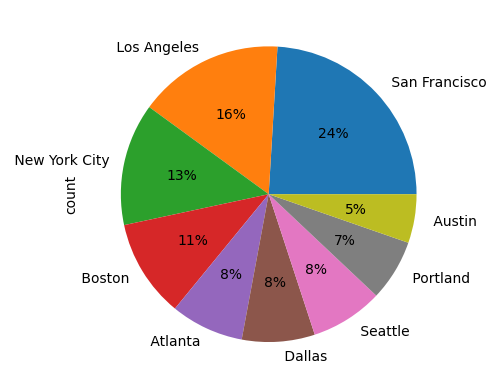

In [43]:
pd.value_counts(all_data['city']).plot(kind='pie' , autopct = '%1.0f%%')

__Order distribution analysis shows that major metropolitan areas such as New York, Los Angeles, and San Francisco contribute the highest volume of orders, likely due to higher population density and stronger purchasing power in these regions.__

# What product sold the most & Why?

In [46]:
all_data.columns

Index(['Order ID', 'Product', 'Quantity Ordered', 'Price Each', 'Order Date',
       'Purchase Address', 'Month', 'sales', 'city'],
      dtype='object')

In [47]:
count_df = all_data.groupby(['Product']).agg({'Quantity Ordered':'sum' , 'Price Each':'mean'})

In [48]:
count_df = count_df.reset_index()

In [49]:
count_df

,Product,Quantity Ordered,Price Each
0,20in Monitor,4126,109.99
1,27in 4K Gaming Monitor,6239,389.99
2,27in FHD Monitor,7541,149.99
3,34in Ultrawide Monitor,6192,379.99
4,AA Batteries (4-pack),27615,3.84
5,AAA Batteries (4-pack),30986,2.99
6,Apple Airpods Headphones,15637,150.00
7,Bose SoundSport Headphones,13430,99.99
8,Flatscreen TV,4813,300.00
9,Google Phone,5529,600.00


In [51]:
products = count_df['Product'].values

C:\Users\admin\AppData\Local\Temp\ipykernel_19916\1444246108.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(products , rotation='vertical' , fontsize=6 )


Text(0, 0.5, 'Avg price of product')

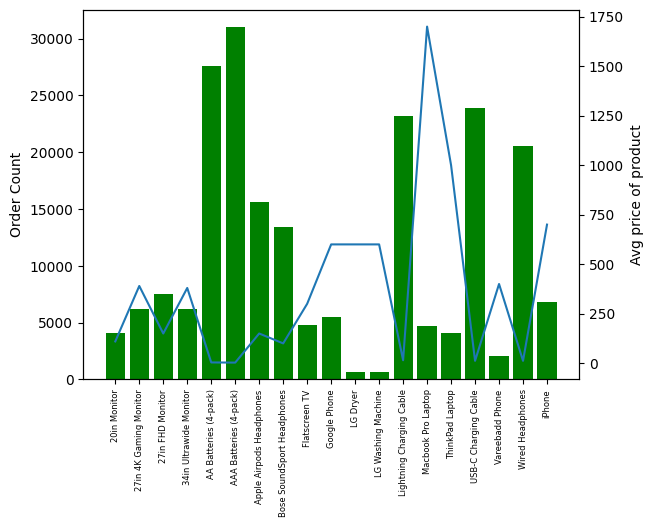

In [52]:
fig , ax1 = plt.subplots()

ax2 = ax1.twinx() ## as X-axis is same for both plots

ax1.bar(count_df['Product'] , count_df['Quantity Ordered'] , color='g')
ax2.plot(count_df['Product'] , count_df['Price Each'] )
ax1.set_xticklabels(products , rotation='vertical' , fontsize=6 )

ax1.set_ylabel('Order Count')
ax2.set_ylabel('Avg price of product')

__This insight suggests that while low-cost items generate high volume, revenue optimization may require balancing high-volume products with higher-margin items.__

# Understanding Trend of the most sold product ?

In [55]:
all_data['Product'].value_counts()[0:5].index  

Index(['USB-C Charging Cable', 'Lightning Charging Cable',
       'AAA Batteries (4-pack)', 'AA Batteries (4-pack)', 'Wired Headphones'],
      dtype='object', name='Product')

In [56]:
most_sold_product = all_data['Product'].value_counts()[0:5].index

In [57]:
all_data['Product'].isin(most_sold_product)

0          True
2         False
3         False
4          True
5          True
          ...  
186845     True
186846    False
186847    False
186848    False
186849     True
Name: Product, Length: 185686, dtype: bool

In [58]:
most_sold_product_df = all_data[all_data['Product'].isin(most_sold_product)]

In [59]:
most_sold_product_df.head(4)

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month,sales,city
0,176558,USB-C Charging Cable,2,11.95,04/19/19 08:46,"917 1st St, Dallas, TX 75001",4,23.90,Dallas
4,176560,Wired Headphones,1,11.99,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001",4,11.99,Los Angeles
5,176561,Wired Headphones,1,11.99,04/30/19 09:27,"333 8th St, Los Angeles, CA 90001",4,11.99,Los Angeles
6,176562,USB-C Charging Cable,1,11.95,04/29/19 13:03,"381 Wilson St, San Francisco, CA 94016",4,11.95,San Francisco


In [60]:
most_sold_product_df.groupby(['Month' , 'Product']).size()

Month  Product                 
1      AA Batteries (4-pack)       1037
       AAA Batteries (4-pack)      1084
       Lightning Charging Cable    1069
       USB-C Charging Cable        1171
       Wired Headphones            1004
2      AA Batteries (4-pack)       1274
       AAA Batteries (4-pack)      1320
       Lightning Charging Cable    1393
       USB-C Charging Cable        1511
       Wired Headphones            1179
3      AA Batteries (4-pack)       1672
       AAA Batteries (4-pack)      1645
       Lightning Charging Cable    1749
       USB-C Charging Cable        1766
       Wired Headphones            1512
4      AA Batteries (4-pack)       2062
       AAA Batteries (4-pack)      1988
       Lightning Charging Cable    2197
       USB-C Charging Cable        2074
       Wired Headphones            1888
5      AA Batteries (4-pack)       1821
       AAA Batteries (4-pack)      1888
       Lightning Charging Cable    1929
       USB-C Charging Cable        1879
       W

In [61]:
pivot = most_sold_product_df.groupby(['Month' , 'Product']).size().unstack()

<Axes: xlabel='Month'>

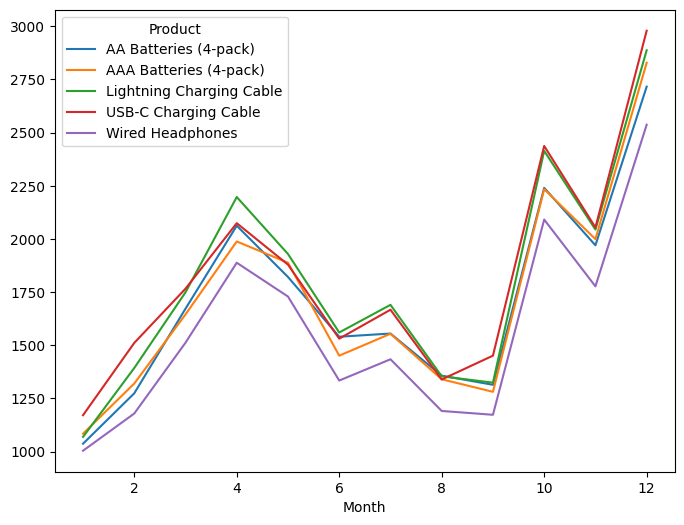

In [62]:
pivot.plot(figsize=(8,6))

__The monthly trend analysis of top-selling products shows a consistent increase in sales during the final quarter (October–December). This pattern suggests strong seasonality, likely driven by holiday demand, festive shopping, and year-end promotions__

# What products are most often sold together ?

In [65]:
all_data['Order ID'] 

0         176558
2         176559
3         176560
4         176560
5         176561
           ...  
186845    259353
186846    259354
186847    259355
186848    259356
186849    259357
Name: Order ID, Length: 185686, dtype: object

In [66]:
df_duplicated = all_data[all_data['Order ID'].duplicated(keep=False)]

In [67]:
df_duplicated 


,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month,sales,city
3,176560,Google Phone,1,600.00,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001",4,600.00,Los Angeles
4,176560,Wired Headphones,1,11.99,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001",4,11.99,Los Angeles
18,176574,Google Phone,1,600.00,04/03/19 19:42,"20 Hill St, Los Angeles, CA 90001",4,600.00,Los Angeles
19,176574,USB-C Charging Cable,1,11.95,04/03/19 19:42,"20 Hill St, Los Angeles, CA 90001",4,11.95,Los Angeles
32,176586,AAA Batteries (4-pack),2,2.99,04/10/19 17:00,"365 Center St, San Francisco, CA 94016",4,5.98,San Francisco
...,...,...,...,...,...,...,...,...,...
186792,259303,AA Batteries (4-pack),1,3.84,09/20/19 20:18,"106 7th St, Atlanta, GA 30301",9,3.84,Atlanta
186803,259314,Wired Headphones,1,11.99,09/16/19 00:25,"241 Highland St, Atlanta, GA 30301",9,11.99,Atlanta
186804,259314,AAA Batteries (4-pack),2,2.99,09/16/19 00:25,"241 Highland St, Atlanta, GA 30301",9,5.98,Atlanta
186841,259350,Google Phone,1,600.00,09/30/19 13:49,"519 Maple St, San Francisco, CA 94016",9,600.00,San Francisco


In [68]:
dup_products = df_duplicated.groupby(['Order ID'])['Product'].apply(lambda x : ','.join(x)).reset_index().rename(columns={'Product':'grouped_products'})

In [69]:
dup_products

,Order ID,grouped_products
0,141275,"USB-C Charging Cable,Wired Headphones"
1,141290,"Apple Airpods Headphones,AA Batteries (4-pack)"
2,141365,"Vareebadd Phone,Wired Headphones"
3,141384,"Google Phone,USB-C Charging Cable"
4,141450,"Google Phone,Bose SoundSport Headphones"
...,...,...
6874,319536,"Macbook Pro Laptop,Wired Headphones"
6875,319556,"Google Phone,Wired Headphones"
6876,319584,"iPhone,Wired Headphones"
6877,319596,"iPhone,Lightning Charging Cable"


In [70]:
dup_products_df = df_duplicated.merge(dup_products , how='left' , on='Order ID')

In [71]:
dup_products_df


,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month,sales,city,grouped_products
0,176560,Google Phone,1,600.00,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001",4,600.00,Los Angeles,"Google Phone,Wired Headphones"
1,176560,Wired Headphones,1,11.99,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001",4,11.99,Los Angeles,"Google Phone,Wired Headphones"
2,176574,Google Phone,1,600.00,04/03/19 19:42,"20 Hill St, Los Angeles, CA 90001",4,600.00,Los Angeles,"Google Phone,USB-C Charging Cable"
3,176574,USB-C Charging Cable,1,11.95,04/03/19 19:42,"20 Hill St, Los Angeles, CA 90001",4,11.95,Los Angeles,"Google Phone,USB-C Charging Cable"
4,176586,AAA Batteries (4-pack),2,2.99,04/10/19 17:00,"365 Center St, San Francisco, CA 94016",4,5.98,San Francisco,"AAA Batteries (4-pack),Google Phone"
...,...,...,...,...,...,...,...,...,...,...
14123,259303,AA Batteries (4-pack),1,3.84,09/20/19 20:18,"106 7th St, Atlanta, GA 30301",9,3.84,Atlanta,"34in Ultrawide Monitor,AA Batteries (4-pack)"
14124,259314,Wired Headphones,1,11.99,09/16/19 00:25,"241 Highland St, Atlanta, GA 30301",9,11.99,Atlanta,"Wired Headphones,AAA Batteries (4-pack)"
14125,259314,AAA Batteries (4-pack),2,2.99,09/16/19 00:25,"241 Highland St, Atlanta, GA 30301",9,5.98,Atlanta,"Wired Headphones,AAA Batteries (4-pack)"
14126,259350,Google Phone,1,600.00,09/30/19 13:49,"519 Maple St, San Francisco, CA 94016",9,600.00,San Francisco,"Google Phone,USB-C Charging Cable"


In [72]:
no_dup_df = dup_products_df.drop_duplicates(subset=['Order ID'])

In [73]:
no_dup_df.shape

(6879, 10)

<Axes: ylabel='count'>

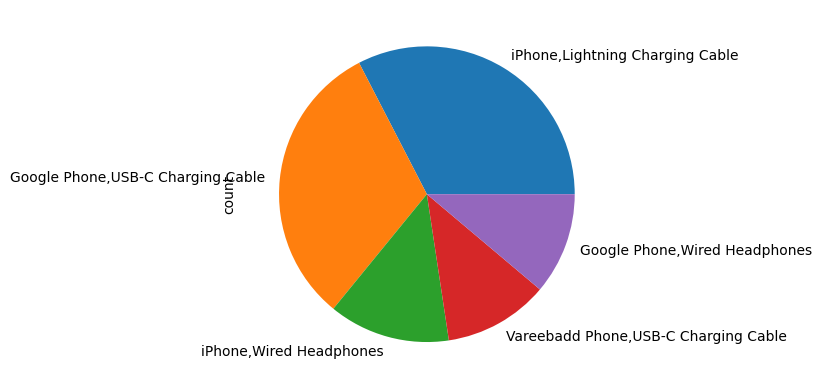

In [74]:
no_dup_df['grouped_products'].value_counts()[0:5].plot.pie()

__Market basket analysis reveals that certain products are frequently purchased together, such as smartphones and charging accessories. This indicates strong cross-selling opportunities, where complementary products can be recommended to increase average order value__

# When do people buy??

In [77]:
all_data.head(5)

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month,sales,city
0,176558,USB-C Charging Cable,2,11.95,04/19/19 08:46,"917 1st St, Dallas, TX 75001",4,23.90,Dallas
2,176559,Bose SoundSport Headphones,1,99.99,04/07/19 22:30,"682 Chestnut St, Boston, MA 02215",4,99.99,Boston
3,176560,Google Phone,1,600.00,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001",4,600.00,Los Angeles
4,176560,Wired Headphones,1,11.99,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001",4,11.99,Los Angeles
5,176561,Wired Headphones,1,11.99,04/30/19 09:27,"333 8th St, Los Angeles, CA 90001",4,11.99,Los Angeles


In [78]:
all_data.dtypes

Order ID             object
Product              object
Quantity Ordered      int32
Price Each          float64
Order Date           object
Purchase Address     object
Month                 int32
sales               float64
city                 object
dtype: object

In [97]:
all_data['Hour'] = pd.to_datetime(all_data['Order Date']).dt.hour

In [80]:
all_data.head(3)

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month,sales,city,Hour
0,176558,USB-C Charging Cable,2,11.95,04/19/19 08:46,"917 1st St, Dallas, TX 75001",4,23.90,Dallas,8
2,176559,Bose SoundSport Headphones,1,99.99,04/07/19 22:30,"682 Chestnut St, Boston, MA 02215",4,99.99,Boston,22
3,176560,Google Phone,1,600.00,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001",4,600.00,Los Angeles,14


<Axes: xlabel='Hour'>

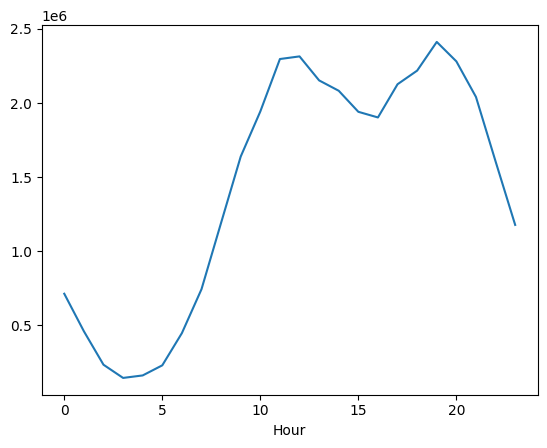

In [81]:
all_data.groupby('Hour')['sales'].sum().plot()

In [82]:
pivot = all_data.pivot_table(index= 'Hour', columns='city', values='sales', aggfunc= 'sum')

In [83]:
pivot

city,Atlanta,Austin,Boston,Dallas,Los Angeles,New York City,Portland,San Francisco,Seattle
Hour,,,,,,,,,
0,62855.02,38095.54,77524.83,45103.93,106176.92,100208.77,46795.29,175921.20,60867.16
1,44443.32,20479.19,48987.45,35310.27,77638.97,71811.12,32359.77,97799.86,31733.95
2,25199.15,15070.52,22018.01,24782.04,34805.51,29175.02,17110.58,50964.17,15714.45
3,7018.49,5957.97,14219.26,14265.28,23673.84,16340.06,11592.08,42127.03,10548.93
4,18954.97,5412.40,21245.82,6769.99,22877.18,20139.72,9621.42,41175.81,16348.76
5,18477.55,12787.88,16447.00,17891.68,37931.63,40200.56,11836.02,53521.90,21570.65
6,39447.56,18528.47,54194.75,36909.89,66811.50,66249.66,34290.75,96635.83,34894.60
7,69861.95,40585.92,68517.54,67286.82,116219.27,101404.71,59898.95,168245.68,52046.48
8,106015.06,60812.95,144361.50,92531.24,172561.11,165058.15,73046.53,283928.39,93994.27


<Axes: xlabel='city', ylabel='Hour'>

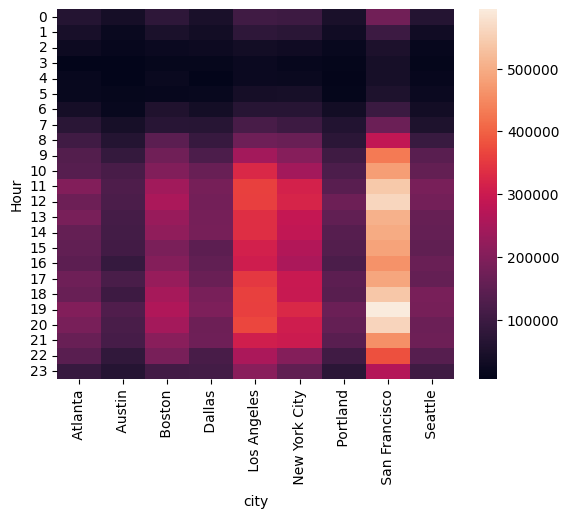

In [84]:
sns.heatmap(pivot
           )

In [85]:
import plotly.express as px

In [86]:
fig = px.imshow(pivot,
                labels = dict(x = 'city', y = 'Hour', color = "Total Sales"),
         x = pivot.columns,
         y = pivot.index,
         title = "Hourly Heatmap Sales By City",
          color_continuous_scale="Inferno")

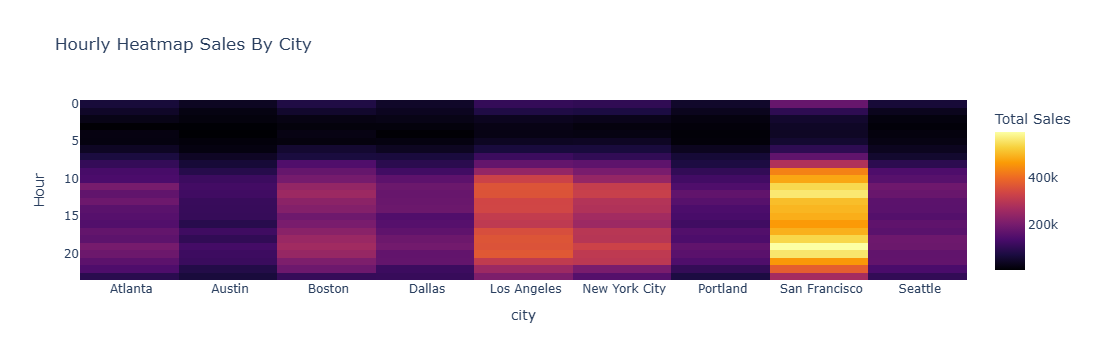

In [87]:
fig

__Hourly sales analysis shows peak purchasing activity during late morning and evening hours, suggesting alignment with typical work breaks and post-work shopping behavior.__